In [1]:
import pandas as pd
import os

In [2]:
folder_path = "."

In [3]:
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

In [4]:
dataframes = []

In [5]:
for file in files:
    df = pd.read_csv(file)
    dataframes.append(df)

In [6]:
data = pd.concat(dataframes, ignore_index=True)

In [7]:
data.head()

,title,artist,description,purchase_price,sale_price,gross_appreciation_multiplier,gross_appreciation_period,url,has_image,image_url
0,Four jackies,ANDY WARHOL (b. 1928 d. 1987),acrylic and silkscreen,$2.2K,$1.9M,859.1x,16 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
1,Lavender marilyn (1),ANDY WARHOL (b. 1928 d. 1987),acrylic and silkscreen ink on canvas,$7.2K,$4.6M,647.5x,25 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
2,Self-portrait,ANDY WARHOL (b. 1928 d. 1987),"""diptych--synthetic polymer, metallic paint an...",$31.2K,$5.7M,182.1x,24 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
3,Smiling jackie,ANDY WARHOL (b. 1928 d. 1987),synthetic polymer and silkscreen inks on canvas,$8K,$1.2M,144x,31 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
4,Flowers,ANDY WARHOL (b. 1928 d. 1987),"""synthetic polymer and silkscreen inks on line...",$46.2K,$4.2M,90.8x,28 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...


In [11]:
def convert_price(price):
    if pd.isna(price):
        return None

    price = str(price).strip()
    
    if price == "" or price.lower() == "purchase_price" or price.lower() == "sale_price":
        return None

    price = price.replace("$", "").replace(",", "")

    try:
        if "M" in price:
            return float(price.replace("M", "")) * 1_000_000
        elif "K" in price:
            return float(price.replace("K", "")) * 1_000
        else:
            return float(price)
    except:
        return None


data["purchase_price"] = data["purchase_price"].apply(convert_price)
data["sale_price"] = data["sale_price"].apply(convert_price)

data[["purchase_price", "sale_price"]].head(10)

,purchase_price,sale_price
0,2200.0,1900000.0
1,7200.0,4600000.0
2,31200.0,5700000.0
3,8000.0,1200000.0
4,46200.0,4200000.0
5,8600.0,736700.0
6,99000.0,8200000.0
7,6300.0,478400.0
8,55200.0,3900000.0
9,3600.0,201600.0


In [12]:
data = data.dropna(subset=["purchase_price", "sale_price"])

data.head()

,title,artist,description,purchase_price,sale_price,gross_appreciation_multiplier,gross_appreciation_period,url,has_image,image_url
0,Four jackies,ANDY WARHOL (b. 1928 d. 1987),acrylic and silkscreen,2200.0,1900000.0,859.1x,16 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
1,Lavender marilyn (1),ANDY WARHOL (b. 1928 d. 1987),acrylic and silkscreen ink on canvas,7200.0,4600000.0,647.5x,25 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
2,Self-portrait,ANDY WARHOL (b. 1928 d. 1987),"""diptych--synthetic polymer, metallic paint an...",31200.0,5700000.0,182.1x,24 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
3,Smiling jackie,ANDY WARHOL (b. 1928 d. 1987),synthetic polymer and silkscreen inks on canvas,8000.0,1200000.0,144x,31 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...
4,Flowers,ANDY WARHOL (b. 1928 d. 1987),"""synthetic polymer and silkscreen inks on line...",46200.0,4200000.0,90.8x,28 years,https://www.masterworks.com/research/artist/an...,True,https://static.masterworks.io/resize/800/maste...


In [13]:
data["roi"] = data["sale_price"] / data["purchase_price"]

data[["purchase_price", "sale_price", "roi"]].head()

,purchase_price,sale_price,roi
0,2200.0,1900000.0,863.636364
1,7200.0,4600000.0,638.888889
2,31200.0,5700000.0,182.692308
3,8000.0,1200000.0,150.000000
4,46200.0,4200000.0,90.909091


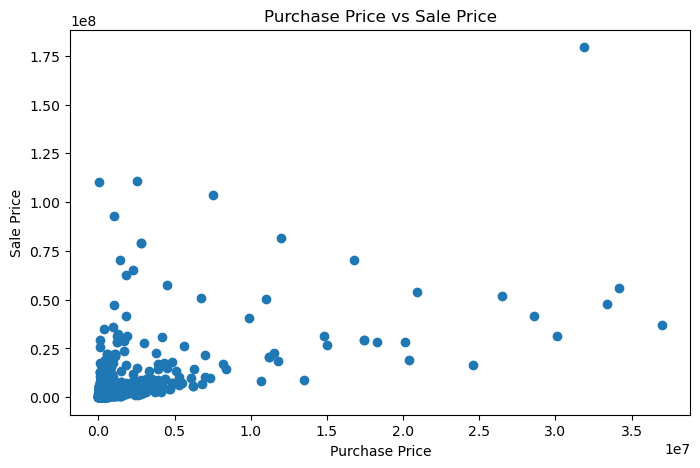

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(data["purchase_price"], data["sale_price"])
plt.xlabel("Purchase Price")
plt.ylabel("Sale Price")
plt.title("Purchase Price vs Sale Price")
plt.show()

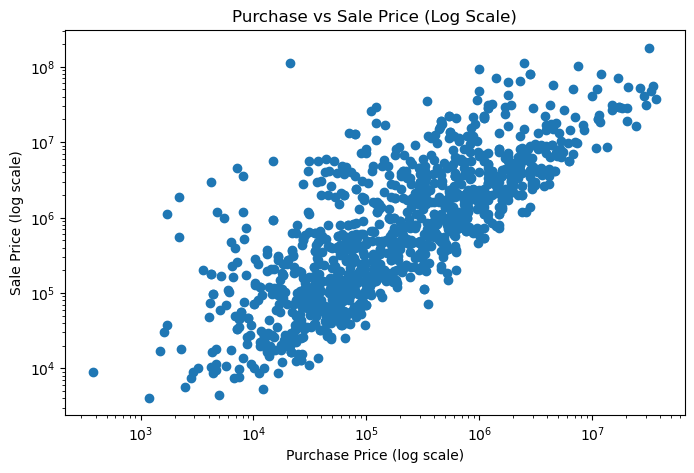

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(data["purchase_price"], data["sale_price"])

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Purchase Price (log scale)")
plt.ylabel("Sale Price (log scale)")
plt.title("Purchase vs Sale Price (Log Scale)")

plt.show()

In [16]:
top_roi = data.sort_values(by="roi", ascending=False)

top_roi[["artist", "purchase_price", "sale_price", "roi"]].head(10)

,artist,purchase_price,sale_price,roi
671,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),20900.0,110500000.0,5287.081340
0,ANDY WARHOL (b. 1928 d. 1987),2200.0,1900000.0,863.636364
672,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),4200.0,3000000.0,714.285714
1063,ZAO WOU KI (b. 1920 d. 2013),1700.0,1100000.0,647.058824
1,ANDY WARHOL (b. 1928 d. 1987),7200.0,4600000.0,638.888889
673,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),8100.0,3600000.0,444.444444
425,FRANCIS BACON (b. 1909 d. 1992),14800.0,5700000.0,385.135135
675,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),2200.0,561000.0,255.000000
674,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),4800.0,1200000.0,250.000000
676,JEAN MICHEL BASQUIAT (b. 1960 d. 1988),122400.0,29300000.0,239.379085


In [17]:
avg_roi = data.groupby("artist")["roi"].mean().sort_values(ascending=False)

avg_roi.head(10)

artist
JEAN MICHEL BASQUIAT (b. 1960 d. 1988)    85.072610
FRANCIS BACON (b. 1909 d. 1992)           31.852862
MARK ROTHKO (b. 1903 d. 1970)             20.195121
ZAO WOU KI (b. 1920 d. 2013)              18.367974
ANDY WARHOL (b. 1928 d. 1987)             12.887193
GERHARD RICHTER (b. 1932)                  8.228766
DAVID HOCKNEY (b. 1937)                    5.803660
CLAUDE MONET (b. 1840 d. 1926)             5.287086
PABLO PICASSO (b. 1881 d. 1973)            3.635791
Name: roi, dtype: float64

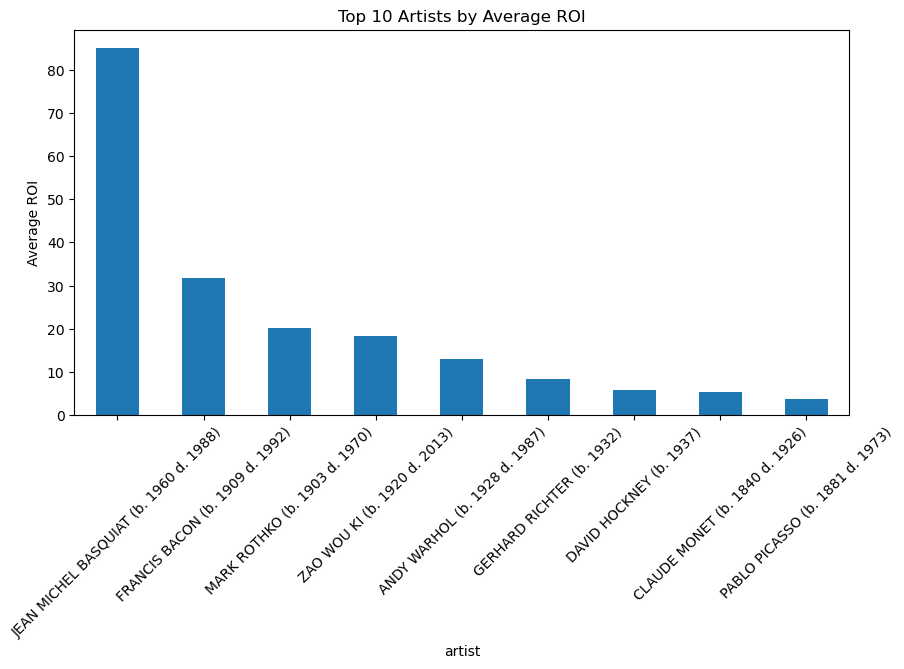

In [18]:
top_artists = avg_roi.head(10)

plt.figure(figsize=(10,5))
top_artists.plot(kind="bar")

plt.title("Top 10 Artists by Average ROI")
plt.ylabel("Average ROI")
plt.xticks(rotation=45)

plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Drop missing values
model_data = data.dropna(subset=["purchase_price", "sale_price"])

# Features (X) and target (y)
X = model_data[["purchase_price"]]
y = model_data["sale_price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

Mean Absolute Error: 3548680.902349858
R^2 Score: 0.13556722239842367
